Vamos a trabajar con el dataset "CALIFORNIA HOUSING PRICES".
El primer paso que debemos de llevar a cabo es el de ver los datos y tratarlos.
Descargamos el dataset desde Kaggle "https://www.kaggle.com/camnugent/california-housing-prices".
Por lo que empezaremos descargando el dataset mediante Kaggle con el siguiente código:

In [349]:
import kagglehub
from pathlib import Path
dataset_path = Path(kagglehub.dataset_download("camnugent/california-housing-prices"))

In [350]:
print(dataset_path) #Mediante esta línea obtenemos la ruta donde se ha guardado el dataset
import shutil
destino = "D:\\Documentos_TheReal\\IA\\PIA\\Apuntes\\Segunda Evaluación\\ia25-master-main\\sergio_ejercicios\\housing_prices\\data" #Guardamos el dataset en la ruta que deseamos para poder trabajar con el
shutil.copytree(dataset_path, destino, dirs_exist_ok=True)

C:\Users\TheRealSerginho\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1


'D:\\Documentos_TheReal\\IA\\PIA\\Apuntes\\Segunda Evaluación\\ia25-master-main\\sergio_ejercicios\\housing_prices\\data'

Una vez tenemos el dataset descargado vamos a proceder a hacer unas comprobaciones básicas de los datos que contiene

In [351]:
import pandas as pd
housing=pd.read_csv("data/housing.csv")

In [352]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [353]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Debemos de comprobar que columnas tienen valores nulos: 

In [354]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Obtenemos que la columna "total_bedrooms" tiene 207 filas con valores nulos, también vimos anteriormente que una de estas columnas no tiene valor numérico, es de tipo str, por lo que para esta variable primero debemos de comprobar que valores puede tener:

In [355]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Podemos obtener un resumen de las estadísticas de todas las columnas con describe(), además este parámetro ignora todas las filas que tengan valores nulos

In [356]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

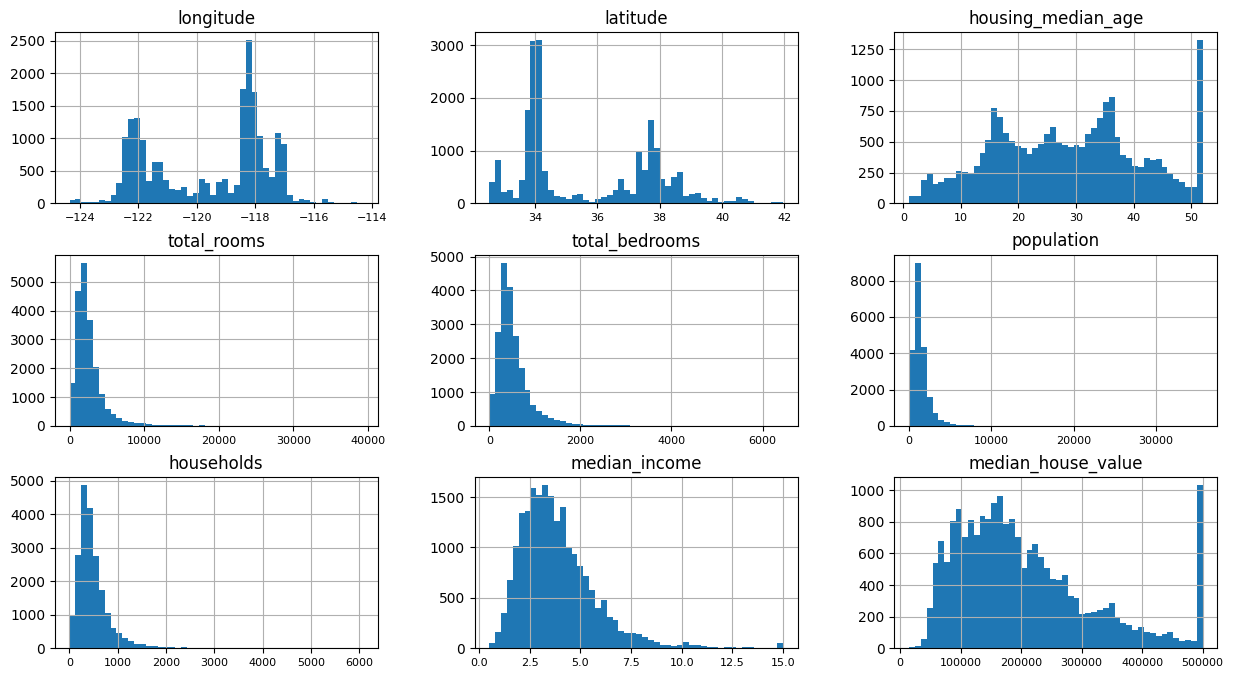

In [357]:
#También podemos obtenerlo en forma de gráficos
housing.hist(bins=50, figsize=(15, 8), #Mediante los bins podemos elegir el número de barras que queremos en el histograma, y con figsize elegimos el tamaño del gráfico
                xlabelsize=8)

En nuestro caso queremos poder deducir la variable del precio, para esto vemos cual de todas las features guarda más relación con nuestra variable.
También tenemos que tener en cuenta que no todo son variables númericas, por lo que primero vamos a extraer las variables numéricas.

In [358]:
corr_matrix = housing.corr(numeric_only=True) 
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

PASO 2. TRATAR LOS VALORES NULOS
Debemos de tener en cuenta que la columna "total_bedrooms" es una variable importante para calcular nuestro objectivo, por lo que a pesar de ser la única columna con valores nulos que solamente son 207, que representa aproximadamente un 1% de todo el dataset, vamos a imputar los valores nulos de esta columna.
Esto lo haremos posteriormente, ya que solamente la imputaremos para el dataset de train y test pero una vez los tenemos separados.
Para imputarlo utilizaremos la MEDIANA ya que es robusta a outliers.


PASO 3. REVISAR SI EXISTEN VARIABLES CATEGÓRICAS.
En nuestro caso ya lo revisamos antes y la única variable categórica de nuestro dataset es "ocean_proximity" y puede tener hasta 5 valores distintos.
Como esta variable no sigue un orden lógico,solamente son valores categóricos en forma de texto utilizaremos One Hot Coding para transformarla a variables numéricas.

In [359]:
housing = pd.get_dummies(housing, columns=["ocean_proximity"], drop_first=True,dtype=int) #Mediante dtype=int establecemos que nos devuelva los valores como 0 o 1, en el caso de no especificarlo nos podría devolver un booleano.
print(housing.columns)
print(housing.shape)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='str')
(20640, 13)


In [360]:
housing.info()
housing.head()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20433 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_INLAND      20640 non-null  int64  
 10  ocean_proximity_ISLAND      20640 non-null  int64  
 11  ocean_proximity_NEAR BAY    20640 non-null  int64  
 12  ocean_proximity_NEAR OCEAN  20640 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 2.0 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


En el caso de que se nos devolviera un booleano lo podriamos convertir mediante:
#cols_bool = housing.select_dtypes(include="bool").columns
#housing[cols_bool] = housing[cols_bool].astype(int)

PASO 4. SEPARAMOS EL DATASET EN TRAIN Y TEST
Ahora vamos a proceder a dividir el dataset, esto lo haremos mediante scikitlearn
Como queremos crear una red neuronal vamos a dividir todo el dataset en 3, de manera que tendremos TRAIN,VALIDATION Y TEST

In [361]:
#Primero vamos a declarar las variables X e Y
#X serán todas las variables del dataset exceptuando la variable que deseamos predecir
X= housing.drop("median_house_value", axis=1)
#Y será la variable que deseamos predecir
y= housing["median_house_value"]

y= np.log1p(y) #Mediante esta función aplicamos el logaritmo a la variable Y para reducir su escala y mejorar el rendimiento del modelo
print("Columnas para X:", X.columns)
print("Forma de X:", X.shape)
print("Columnas para Y:", y.name)
print("Forma de Y:", y.shape)


Columnas para X: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='str')
Forma de X: (20640, 12)
Columnas para Y: median_house_value
Forma de Y: (20640,)


In [362]:
#Ahora procedemos a dividir el dataset en dos, el entrenamiento y los que posteriormente utilizaremos para evaluar el modelo. Para ello utilizaremos la función train_test_split de sklearn, que nos permite dividir el dataset de forma aleatoria.
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
len(X_train), len(X_temp)

(14448, 6192)

In [363]:
#Procedemos a dividir el conjunto temporal en dos, serán el conjunto de validación y el conjunto de test
X_val, X_test, y_val, y_test= train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print("Tamaño del conjunto de entrenamiento:", len(X_train))
print("Tamaño del conjunto de validación:", len(X_val)) 
print("Tamaño del conjunto de test:", len(X_test))

Tamaño del conjunto de entrenamiento: 14448
Tamaño del conjunto de validación: 3096
Tamaño del conjunto de test: 3096


PASO 5. ESCALADO DE LAS VARIABLES.
Antes de comenzar a escalar debemos imputar los valores de la columna "total_bedrooms" que son nulos como dijimos anteriormente.
Por lo que los vamos a imputar con la mediana de la siguiente manera

In [364]:
#La mediana debemos de calcular solamente en el conjunto de ENTRENAMIENTO, esto lo hacemos para evitar el DATALEAK
mediana_bedrooms= X_train["total_bedrooms"].median()
print("Mediana de total_bedrooms en el conjunto de entrenamiento:", mediana_bedrooms)

Mediana de total_bedrooms en el conjunto de entrenamiento: 437.0


In [365]:
#Ahora vamos a rellenar todos los valores nulos para esta columna con el valor que acabamos de calcular
X_train["total_bedrooms"].fillna(mediana_bedrooms, inplace=True)
X_val["total_bedrooms"].fillna(mediana_bedrooms, inplace=True)
X_test["total_bedrooms"].fillna(mediana_bedrooms, inplace=True)

C:\Users\TheRealSerginho\AppData\Local\Temp\ipykernel_13996\414148655.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X_train["total_bedrooms"].fillna(mediana_bedrooms, inplace=True)
C:\Users\TheRealSerginho\AppData\Local\Temp\ipykernel_13996\414148655.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or

2457     319.0
12273    886.0
4081     617.0
15537     13.0
2915     234.0
         ...  
9742     230.0
15840    623.0
12181    576.0
5139     688.0
17095    433.0
Name: total_bedrooms, Length: 3096, dtype: float64

In [366]:
#Comprobamos que ya no existen valores nulos
print(X_train["total_bedrooms"].isna().sum())
print(X_val["total_bedrooms"].isna().sum())
print(X_test["total_bedrooms"].isna().sum())


0
91
116


In [367]:
#Comprobando el error anterior podemos ver que nos dice que pandas trabaja sobre una copia y no el dataframe original, esto se debe a que al hacer la división del dataset, pandas crea una copia de los datos y no trabaja sobre el dataframe original, para solucionarlos hacemos lo siguiente:
X_train["total_bedrooms"] = X_train["total_bedrooms"].fillna(mediana_bedrooms)
X_val["total_bedrooms"] = X_val["total_bedrooms"].fillna(mediana_bedrooms)
X_test["total_bedrooms"] = X_test["total_bedrooms"].fillna(mediana_bedrooms)

In [368]:
#Comprobamos que ya no existen valores nulos
print(X_train["total_bedrooms"].isna().sum())
print(X_val["total_bedrooms"].isna().sum())
print(X_test["total_bedrooms"].isna().sum())


0
0
0


In [369]:
#Procedemos a escalar las variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #Creamos el objeto escalador
scaler.fit(X_train) #Ajustamos el escalador a los datos de entrenamiento

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [370]:
#Creamos tres variables en las que almacenaremos los datos escalados de cada conjunto
X_train_scaled= scaler.transform(X_train)
X_val_scaled= scaler.transform(X_val)
X_test_scaled= scaler.transform(X_test)

In [371]:
#Comprobamos si funcionó correctamente
X_train_scaled.mean()
X_train_scaled.std()

np.float64(1.0)

VER SI DEBO TRATAR OUTLIER, EN ESE CASO DEBE SER ANTES DE ESCALAR


Paso 6. Convertir los datos a tensores
Primero vamos a comprobar que tipo de datos tenemos

In [372]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
print (type(X))
print (type(y))


<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [373]:
#Como son datos de pandas los debemos de convertir a Numpy para poder trabajar con Pytorch
X = X.values
y = y.values
print (type(X))
print (type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [374]:
print(X.dtype)
print (y.dtype)

float64
float64


In [375]:
print(type(y_train))
print(type(y_val))
print(type(y_test))

<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>


Una cosa muy importante es que Pytorch trabaja con float32, no con float64, por lo que debemos de convertirlo a este tipo

In [376]:
#Convertimos X
X_train_scaled = X_train_scaled.astype("float32")
X_val_scaled = X_val_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")

#Convertimos Y a float32 y le damos forma de vector para poder procesarlo posteriormente con Pytorch
y_train = y_train.to_numpy().astype("float32").reshape(-1, 1)
y_val = y_val.to_numpy().astype("float32").reshape(-1, 1)
y_test = y_test.to_numpy().astype("float32").reshape(-1, 1)


In [377]:
print(X_train_scaled.dtype)
print(type(y_train), y_train.dtype, y_train.shape)
print(type(y_val), y_val.dtype, y_val.shape)
print(type(y_test), y_test.dtype, y_test.shape)

float32
<class 'numpy.ndarray'> float32 (14448, 1)
<class 'numpy.ndarray'> float32 (3096, 1)
<class 'numpy.ndarray'> float32 (3096, 1)


In [378]:
#Ahora que tenemos todos los datos de la forma correcta procedemos a craer los tensores de Pytorch
import torch
X_train_tensor= torch.tensor(X_train_scaled)
y_train_tensor= torch.tensor(y_train)
X_val_tensor= torch.tensor(X_val_scaled)
y_val_tensor= torch.tensor(y_val)
X_test_tensor= torch.tensor(X_test_scaled)
y_test_tensor= torch.tensor(y_test)

Ahora procedemos a crear el DATALOADER Y EL DATASET
Esto lo hacemos porque no se entrena con todos los datos a la vez, sino que entrenamos en lotes que son los batches
Esto nos da un mejor rendimiento y hace el entrenamiento sea más estable

In [379]:
#Creamos el dataset
from torch.utils.data import TensorDataset
train_dataset= TensorDataset(X_train_tensor,y_train_tensor)
val_dataset= TensorDataset(X_val_tensor, y_val_tensor)
test_dataset= TensorDataset(X_test_tensor, y_test_tensor)


In [380]:
#Siguiente paso es crear el DATALOADER, que nos permite cargar los datos en batches para entrenar el modelo de forma más eficiente, además de permitirnos mezclar los datos de forma aleatoria en cada época.
from torch.utils.data import DataLoader
train_dataloader= DataLoader(train_dataset, batch_size=32, shuffle=True) #con true establecemos que mezcle datos
val_dataloader= DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader= DataLoader(test_dataset, batch_size=32, shuffle=False)

In [381]:
#Procedemos a crear la red neuronal
#Comprobamos la dimensión de los datos para crear la red neuronal
print(X_train_tensor.shape) #Esto nos dice que tenemos 14448 muestras y 9 características, por lo que la capa de entrada de nuestra red neuronal debe tener 9 neuronas
print(y_train_tensor.shape) #Esto nos dice que tenemos 14448 muestras y 1

torch.Size([14448, 12])
torch.Size([14448, 1])


In [382]:
import torch.nn as nn

class CaliforniaModel(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim):
        super(CaliforniaModel, self).__init__()
        
        # Capa de entrada -> capa oculta
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()

        # Capa oculta -> capa oculta    
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()

        #Capa oculta -> capa de salida
        self.fc3 = nn.Linear(hidden_dim2, output_dim)

    def forward(self, x):
        # Propagación hacia adelante
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x= self.relu2(x)
        x= self.fc3(x)
        return x

# Parámetros
input_dim = X_train.shape[1]  # Número de características de entrada
hidden_dim1 = 64  # Número de neuronas en la capa oculta
hidden_dim2 = 32  # Número de neuronas en la segunda capa oculta
output_dim = 1  # 

# Crear el modelo
model = CaliforniaModel(input_dim, hidden_dim1, hidden_dim2, output_dim)

No utilizamos ni Sigmoid ni softmax ya que es un regresión

Ahora pasamos a definir la función de pérdida
Como estamos ante un problema de regresión utilizaremos MSELoss

In [383]:
criterion = nn.MSELoss()

Vamos a definir el optimizador, que es el encargado de actualizar los parámetros del modelo para minimizar la función de pérdida.
Para este caso usaremos Adam que es rápido y eficaz

In [384]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
#lr es la tasa de aprendizaje, indica cuanto de largos son los pasos que vamos dando.

Empezamos el entrenamiento

Epoch [5/100], Loss Train: 0.1146, Loss Val: 0.1254
Epoch [10/100], Loss Train: 0.0911, Loss Val: 0.0978
Epoch [15/100], Loss Train: 0.0904, Loss Val: 0.1025
Epoch [20/100], Loss Train: 0.0839, Loss Val: 0.0888
Epoch [25/100], Loss Train: 0.0833, Loss Val: 0.1070
Epoch [30/100], Loss Train: 0.0892, Loss Val: 0.0852
Epoch [35/100], Loss Train: 0.0770, Loss Val: 0.0822
Epoch [40/100], Loss Train: 0.0762, Loss Val: 0.0807
Epoch [45/100], Loss Train: 0.0793, Loss Val: 0.0808
Epoch [50/100], Loss Train: 0.0744, Loss Val: 0.0888
Epoch [55/100], Loss Train: 0.0728, Loss Val: 0.0776
Early stopping en la época 57


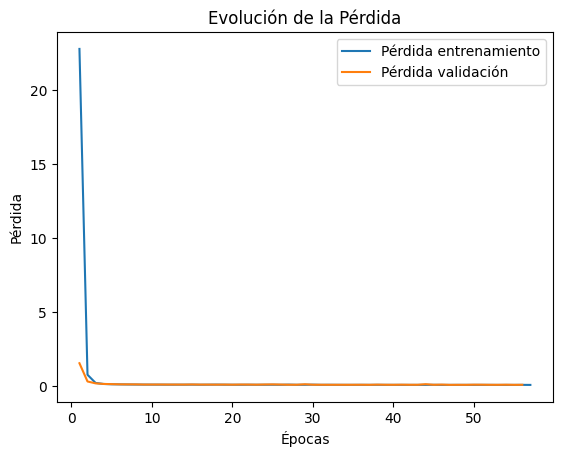

In [385]:
train_loss = [] #Lista para almacenar la pérdida de entrenamiento en cada época
val_loss = [] #Lista para almacenar la pérdida de validación en cada época

num_epochs= 100

best_val_loss = float("inf")
patience = 10
counter = 0

for epoch in range(num_epochs):
    model.train() #Ponemos el modelo en modo entrenamiento
    running_train_loss = 0.0
    for batch_X, batch_y in train_dataloader:
        optimizer.zero_grad() #Ponemos a cero los gradientes para evitar que se acumulen

        outputs= model(batch_X) #Forward
        loss= criterion(outputs,batch_y) #Calculamos la pérdida

        loss.backward() #Calculamos los gradientes
        optimizer.step() #Actualizar pesos
        running_train_loss += loss.item() #Sumamos la pérdida de este batch

    epoch_train_loss = running_train_loss / len(train_dataloader) #Calculamos la pérdida media de la época
    train_loss.append(epoch_train_loss) #Almacenamos la pérdida de entrenamiento de esta época


    model.eval() #Ponemos el modelo en modo evaluación
    running_val_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_dataloader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_dataloader)
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
    if counter >= patience:
        print(f"Early stopping en la época {epoch+1}")
        break
    val_loss.append(epoch_val_loss)

        # Imprimir progreso cada 5 épocas

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss Train: {epoch_train_loss:.4f}, Loss Val: {epoch_val_loss:.4f}")
model.load_state_dict(torch.load("best_model.pth"))
# Al final, podrás graficar las pérdidas:
import matplotlib.pyplot as plt

#plt.plot(range(1, num_epochs+1), train_loss, label="Pérdida entrenamiento")
#plt.plot(range(1, num_epochs+1), val_loss, label="Pérdida validación")
plt.plot(range(1, len(train_loss)+1), train_loss, label="Pérdida entrenamiento") #Utilizamos esta debido a la implementación de early stopping, ya que el número de épocas puede ser menor a num_epochs
plt.plot(range(1, len(val_loss)+1), val_loss, label="Pérdida validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de la Pérdida")
plt.legend()
plt.show()


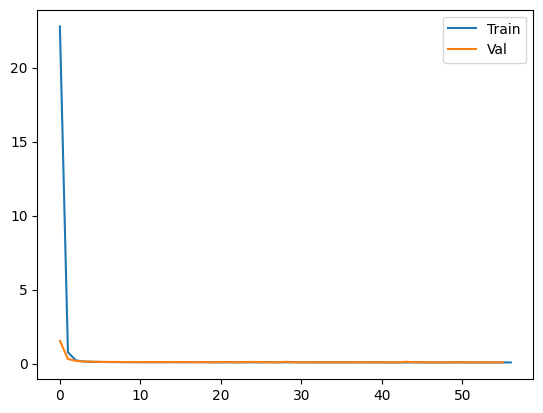

In [386]:
import matplotlib.ticker as ticker

plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Val")

plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.ticklabel_format(style='plain', axis='y')

plt.legend()
plt.show()

In [387]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Modo evaluación
model.eval()

y_pred = []

# Obtener predicciones
with torch.no_grad():
    for batch_X, _ in test_dataloader:
        outputs = model(batch_X)
        y_pred.append(outputs)

# Unir batches
y_pred = torch.cat(y_pred, dim=0)

# Pasar a numpy
y_pred = y_pred.cpu().numpy()
y_true = y_test  # ya esta en numpy

# Asegurar misma forma
y_pred = y_pred.flatten()
y_true = y_true.flatten()

y_pred = np.expm1(y_pred)
y_true = np.expm1(y_true)

# Calcular métricas
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}$ error  por casa")
print(f"MAE: {mae:.2f}$ error medio por casa")

MSE: 3035947264.00
RMSE: 55099.43$ error  por casa
MAE: 37345.34$ error medio por casa


Como podemos ver obtenemos que el RMSE>MAE, esto significa que tenemos outliers.

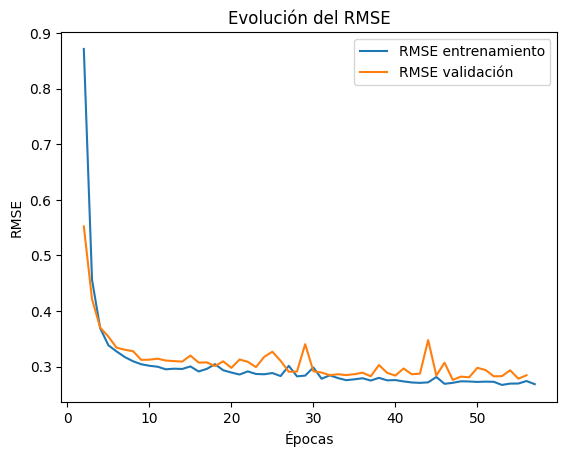

In [388]:
train_rmse = [np.sqrt(x) for x in train_loss] #Mediante np.sqrt(x) lo convertimos en raíz cuadrada para obtener el RMSE, que es una métrica más interpretable que la pérdida MSE
val_rmse = [np.sqrt(x) for x in val_loss]

#plt.plot(range(2, num_epochs+1), train_rmse[1:], label="RMSE entrenamiento")#Quitamos la primera época porque suele ser muy alta y distorsiona la gráfica
#plt.plot(range(2, num_epochs+1), val_rmse[1:], label="RMSE validación")#Empieza en la época 2 porque quitamos la primera
plt.plot(range(2, len(train_rmse)+1), train_rmse[1:], label="RMSE entrenamiento")
plt.plot(range(2, len(val_rmse)+1), val_rmse[1:], label="RMSE validación")
plt.xlabel("Épocas")
plt.ylabel("RMSE")
plt.title("Evolución del RMSE")
plt.legend()
plt.show()

De esta manera nos queda una gráifca más interpretable.
-Por último, se realizó una prueba de la misma red neuronal pero con 3 capas ocultas, los resultados obtenidos con la red de 2 capas ocultas fueron mejores y por eso finalmente es la opción escogida.
-Se puede ver que la red aprende bien, no existe overfiting, la validación no se adapta al entrenamiento.
-Una mejora aplicada fue la de escalar la variable target, la variable y se escaló con log1p ya que existían algunos outliers que generaban bastantes problemas en nuestra red neuronal.
-De esta manera tenemos como conclusión que el RMSE que obtuvimos es de alrededor de 57000$ por casa y el error medio de 38000$.
-La pérdida de validación desciende de forma clara durante las primeras épocas y, a partir de aproximadamente la época 75, las mejoras se vuelven marginales y aparecen oscilaciones. Aunque el mejor valor de validación observado se alcanza en torno a la época 90, la diferencia respecto a épocas anteriores es pequeña, por lo que sería recomendable aplicar early stopping para detener el entrenamiento cuando deje de haber mejoras significativas.
-Se añadió una parte de código al entrenamiento, se implementó un eary stopping para que en el caso de que la pérdida en validación no mejore en 10 epochs se pare el entrenamiento, de esta forma hacemos menos entrenamiento que sea innecesario, evitamos sobreajusta y ahorramos tiempo.